## 07 — Export Models to ONNX

Converts all three trained XGBoost models to ONNX format for browser inference via `onnxruntime-web`.  
Uses `onnxmltools.convert_xgboost()` which writes standard ONNX protobuf (compatible with all onnxruntime versions).  

**Prerequisites:** run notebooks 04, 05, 06 first to generate the `.pkl` files.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import onnxruntime as rt
import warnings
warnings.filterwarnings('ignore')

from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
from feature_engineering import prepare_with_features

plt.style.use('dark_background')
ACCENT  = '#3b82f6'
SUCCESS = '#22c55e'
MODELS_DIR = os.path.join('..', 'models')

print('Libraries loaded')
print(f'onnxruntime version: {rt.__version__}')

Libraries loaded
onnxruntime version: 1.26.0


### 1. Check Trained Models Exist

In [2]:
model_configs = [
    ('wait_time_model.pkl',    'wait_time_model.onnx',    'regression'),
    ('outcome_model.pkl',      'outcome_model.onnx',      'classification'),
    ('satisfaction_model.pkl', 'satisfaction_model.onnx', 'regression'),
]

all_present = True
for pkl, onnx, task in model_configs:
    exists = os.path.exists(os.path.join(MODELS_DIR, pkl))
    status = 'OK' if exists else 'MISSING — run training notebook first'
    print(f'{pkl:<28}  {status}')
    if not exists:
        all_present = False

print(f'\nAll models present: {all_present}')

wait_time_model.pkl           OK
outcome_model.pkl             OK
satisfaction_model.pkl        OK

All models present: True


### 2. Export Helper

In [3]:
def export_xgb_onnx(pkl_name, onnx_name):
    """Load pkl, convert to ONNX via onnxmltools, write to disk."""
    bundle = joblib.load(os.path.join(MODELS_DIR, pkl_name))
    model  = bundle['model']
    feat   = bundle['feature_names']
    n      = len(feat)

    # onnxmltools requires numeric feature indices — temporarily strip names
    booster = model.get_booster()
    original_names = booster.feature_names
    booster.feature_names = None
    try:
        initial_type = [('float_input', FloatTensorType([None, n]))]
        onnx_model   = convert_xgboost(model, initial_types=initial_type, target_opset=12)
    finally:
        booster.feature_names = original_names  # always restore

    onnx_path = os.path.join(MODELS_DIR, onnx_name)
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())

    size_kb = os.path.getsize(onnx_path) / 1024
    print(f'Exported  {onnx_name:<30}  {size_kb:.1f} KB  ({n} features)')
    return onnx_path, feat

print('Helper defined')

Helper defined


### 3. Export All Three Models

In [4]:
exported = {}
for pkl, onnx_name, task in model_configs:
    if not os.path.exists(os.path.join(MODELS_DIR, pkl)):
        print(f'Skipping {pkl}')
        continue
    onnx_path, feat = export_xgb_onnx(pkl, onnx_name)
    exported[onnx_name] = {'path': onnx_path, 'features': feat, 'task': task}

print(f'\nExported {len(exported)} models')

Exported  wait_time_model.onnx            188.5 KB  (16 features)
Exported  outcome_model.onnx              670.8 KB  (16 features)
Exported  satisfaction_model.onnx         189.8 KB  (16 features)

Exported 3 models


### 4. Verify — Wait Time Model

In [5]:
splits   = prepare_with_features()
X_sample = splits['X_test'].values[:5].astype(np.float32)

# Load sklearn model for comparison
bundle_wt = joblib.load(os.path.join(MODELS_DIR, 'wait_time_model.pkl'))
sk_pred   = bundle_wt['model'].predict(X_sample)

# ONNX inference
sess  = rt.InferenceSession(exported['wait_time_model.onnx']['path'],
                             providers=['CPUExecutionProvider'])
iname = sess.get_inputs()[0].name
onnx_pred = sess.run(None, {iname: X_sample})[0].flatten()

print('Wait Time — sklearn vs ONNX (5 samples):')
for i, (sk, on) in enumerate(zip(sk_pred, onnx_pred)):
    print(f'  [{i}]  sklearn={sk:.2f}  onnx={on:.2f}  diff={abs(sk-on):.6f}')
print(f'\nMax diff: {np.abs(sk_pred - onnx_pred).max():.8f}')

Wait Time — sklearn vs ONNX (5 samples):
  [0]  sklearn=257.00  onnx=257.00  diff=0.000092
  [1]  sklearn=5.21  onnx=5.21  diff=0.000059
  [2]  sklearn=14.87  onnx=14.87  diff=0.000024
  [3]  sklearn=29.88  onnx=29.88  diff=0.000000
  [4]  sklearn=47.46  onnx=47.46  diff=0.000015

Max diff: 0.00009155


### 5. Verify — Outcome Classifier

In [6]:
bundle_oc = joblib.load(os.path.join(MODELS_DIR, 'outcome_model.pkl'))
sk_labels = bundle_oc['model'].predict(X_sample)
sk_proba  = bundle_oc['model'].predict_proba(X_sample)[:, 1]

sess_oc = rt.InferenceSession(exported['outcome_model.onnx']['path'],
                               providers=['CPUExecutionProvider'])
iname   = sess_oc.get_inputs()[0].name
oc_out  = sess_oc.run(None, {iname: X_sample})

onnx_labels = np.array(oc_out[0])

# Probabilities may come as array or list-of-dicts depending on onnxmltools version
raw_proba = oc_out[1]
if isinstance(raw_proba, np.ndarray):
    onnx_proba = raw_proba[:, 1]
else:
    onnx_proba = np.array([d.get(1, d.get('1', 0.0)) for d in raw_proba])

print('Outcome Classifier — sklearn vs ONNX:')
print(f'  sklearn labels : {sk_labels}')
print(f'  onnx labels    : {onnx_labels}')
print(f'  sklearn proba  : {sk_proba.round(4)}')
print(f'  onnx proba     : {onnx_proba.round(4)}')
print(f'\nLabel match: {np.array_equal(sk_labels, onnx_labels)}')

Outcome Classifier — sklearn vs ONNX:
  sklearn labels : [0 0 0 0 0]
  onnx labels    : [0 0 0 0 0]
  sklearn proba  : [0.3662 0.1072 0.1632 0.4156 0.2285]
  onnx proba     : [0.3662 0.1072 0.1632 0.4156 0.2285]

Label match: True


### 6. Verify — Satisfaction Model

In [7]:
bundle_sat = joblib.load(os.path.join(MODELS_DIR, 'satisfaction_model.pkl'))
sk_pred_sat = bundle_sat['model'].predict(X_sample)

sess_sat = rt.InferenceSession(exported['satisfaction_model.onnx']['path'],
                                providers=['CPUExecutionProvider'])
iname = sess_sat.get_inputs()[0].name
onnx_pred_sat = sess_sat.run(None, {iname: X_sample})[0].flatten()

print('Satisfaction — sklearn vs ONNX (5 samples):')
for i, (sk, on) in enumerate(zip(sk_pred_sat, onnx_pred_sat)):
    print(f'  [{i}]  sklearn={sk:.3f}  onnx={on:.3f}  diff={abs(sk-on):.6f}')
print(f'\nMax diff: {np.abs(sk_pred_sat - onnx_pred_sat).max():.8f}')

Satisfaction — sklearn vs ONNX (5 samples):
  [0]  sklearn=0.911  onnx=0.911  diff=0.000001
  [1]  sklearn=4.674  onnx=4.674  diff=0.000005
  [2]  sklearn=4.550  onnx=4.550  diff=0.000001
  [3]  sklearn=4.058  onnx=4.058  diff=0.000004
  [4]  sklearn=3.420  onnx=3.420  diff=0.000000

Max diff: 0.00000477


### 7. ONNX Model Summary

                  Model           Task  Size (KB)  Features  Outputs
   wait_time_model.onnx     regression      188.5        16        1
     outcome_model.onnx classification      670.8        16        2
satisfaction_model.onnx     regression      189.8        16        1


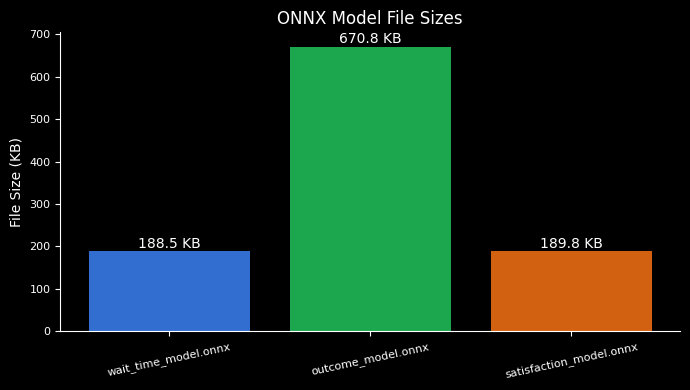


All ONNX models ready for upload to Supabase Storage.


In [8]:
rows = []
for pkl, onnx_name, task in model_configs:
    onnx_path = os.path.join(MODELS_DIR, onnx_name)
    if not os.path.exists(onnx_path):
        continue
    sess = rt.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    rows.append({
        'Model': onnx_name,
        'Task': task,
        'Size (KB)': round(os.path.getsize(onnx_path) / 1024, 1),
        'Features': len(exported[onnx_name]['features']),
        'Outputs': len(sess.get_outputs()),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = [ACCENT, '#22c55e', '#f97316']
bars = ax.bar(df['Model'], df['Size (KB)'], color=colors, alpha=0.85)
for bar, val in zip(bars, df['Size (KB)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val} KB', ha='center', va='bottom', color='white', fontsize=10)
ax.set_ylabel('File Size (KB)', color='white')
ax.set_title('ONNX Model File Sizes', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=8)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

print('\nAll ONNX models ready for upload to Supabase Storage.')